<a href="https://colab.research.google.com/github/AyushiB56/Neural-Network/blob/main/Regularization_L1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch.nn as nn
import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
display.set_matplotlib_formats('svg')
import torch.nn.functional as F

#It sets the output format of Matplotlib plots in Jupyter/IPython notebooks to SVG (Scalable Vector Graphics) instead of the default PNG.


from torch.utils.data import TensorDataset, DataLoader

import numpy as np


<ipython-input-1-d596777a1555>:6: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
def create_train_test_dataset(dataset):
  labels = torch.tensor((np.zeros(len(dataset))), dtype= torch.long)
  X = torch.tensor(dataset.drop("species", axis=1).values, dtype=torch.float32)
  labels[np.where(dataset['species']=='versicolor' )]=1
  labels[np.where(dataset['species']=='virginica' )]=2
  X_train,x_test,y_train,y_test= train_test_split(X, labels, test_size=0.2)
  X_train_tensor= TensorDataset(X_train,y_train)
  X_test_tensor= TensorDataset(x_test,y_test)

  X_y_train_dataloader= DataLoader(X_train_tensor, batch_size=16, shuffle = True, drop_last= True)
  X_y_test_dataloader= DataLoader(X_test_tensor, batch_size=16, shuffle = True, drop_last= True)

  return X_y_train_dataloader,X_y_test_dataloader






In [6]:
class Neural_model_1(nn.Module):
  def __init__(self,dropRate=0):
    super().__init__()


    self.layer1= nn.Linear(4,64)
    self.hidden= nn.Linear(64,128)
    self.output= nn.Linear(128,3)

    self.dropRate= dropRate
  def forward(self,x):
      x= torch.relu(self.layer1(x))
      x= F.dropout(x, p=self.dropRate, training= self.training)
      x= torch.relu(self.hidden(x))
      x= F.dropout(x, p=self.dropRate, training= self.training)
      x= self.output(x)

      return x




In [8]:
def create_model(L2rate,dropRate=0):
  model = Neural_model_1(dropRate)
  loss= nn.CrossEntropyLoss()
  optimizer= torch.optim.Adam(model.parameters(), lr=0.001)
  return model, loss, optimizer

In [34]:
def training(dataset,L1rate,dropRate=0):
  X_y_train_dataloader,X_y_test_dataloader=create_train_test_dataset(dataset)
  model, loss, optimizer=create_model(L1rate,dropRate)
  nweight=0
  for pname, i in model.named_parameters():
    if 'bias' not in pname:
      nweight=nweight+i.numel()


  nepoch = 1000
  train_loss=[]
  test_loss= []



  for epoch in range(nepoch):
    model.train()
    loss_fn=0
    loss_train_batch=[]
    loss_test_batch=[]
    for x,y in X_y_train_dataloader:
        L1term= torch.tensor(0.0, requires_grad=True)
        for pname, weight in model.named_parameters():
           if 'bias' not in pname:
                L1term=L1term+torch.sum(torch.abs(weight))


        yhat= model(x)
        loss_fn= loss(yhat,y)

        loss_fn= loss_fn + L1rate * (L1term/nweight)

        optimizer.zero_grad()
        loss_fn.backward()
        optimizer.step()

        loss_train_batch.append(loss_fn.item())


    train_loss.append(np.mean(loss_train_batch))

    model.eval()
    with torch.no_grad():
      for x,y in X_y_test_dataloader:

          yhat= model(x)
          loss_fn= loss(yhat,y)
          loss_test_batch.append(loss_fn.item())

      test_loss.append(np.mean(loss_test_batch))

  return train_loss,test_loss





In [35]:
def smooth(x,k=5):
  return np.convolve(x,np.ones(k)/k, mode= 'same')

In [36]:
import seaborn as sns
iris_data= sns.load_dataset('iris')

def evaluation():
  L1rate= np.linspace(0,.1,10)
  loss_l1_train= np.zeros((1000,len(L1rate)))
  loss_l1_test= np.zeros((1000,len(L1rate)))
  for i in range(len(L1rate)):
    train_loss,test_loss=training(iris_data,L1rate[i])
    loss_l1_train[:,i]=smooth(train_loss,10)
    loss_l1_test[:,i]=smooth(test_loss,10)



  return loss_l1_train,loss_l1_test,L1rate


In [37]:
train_loss,test_loss,rate=evaluation()

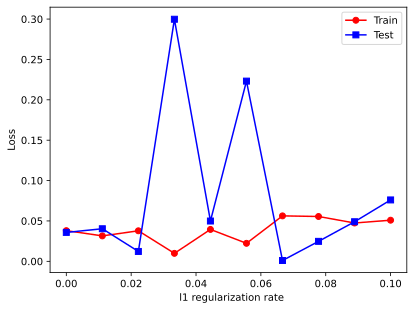

In [41]:
epoch_range=[500,950]

plt.plot(rate,np.mean(train_loss[epoch_range[0]:epoch_range[1],:], axis=0), 'ro-', label= 'Train' )
plt.plot(rate,np.mean(test_loss[epoch_range[0]:epoch_range[1],:], axis=0), 'bs-',label= 'Test' )
plt.xlabel("  l1 regularization rate")
plt.ylabel('Loss')
plt.legend()
plt.show()